# UVW College Enrollment Analytics
This notebook analyzes demographic and income patterns using the UCI Adult Income dataset.

## Goal
Use demographic and employment features to understand which groups are more likely to earn more than \$50K and translate those findings into marketing insights for a hypothetical college enrollment use case.

## 1. Imports and Data Loading
This section loads the dataset from the UCI Adult repository and assigns descriptive column names.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_style("whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv(
    url,
    names=column_names,
    na_values=" ?",
    skipinitialspace=True
)

df.replace("?", None, inplace=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Basic Inspection
Check shape, data types, and missing values before analysis.

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Shape: (32561, 15)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Missing values:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


## 3. Data Preparation
Clean a few fields and standardize formatting for downstream analysis.

In [3]:
df["income"] = df["income"].str.strip()

education_order = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th",
    "12th", "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm",
    "Bachelors", "Masters", "Prof-school", "Doctorate"
]

df["education"] = pd.Categorical(
    df["education"],
    categories=education_order,
    ordered=True
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 4. Analysis 1: Age and Income
Following the original project code, group by age and income and compare the counts with a line chart.

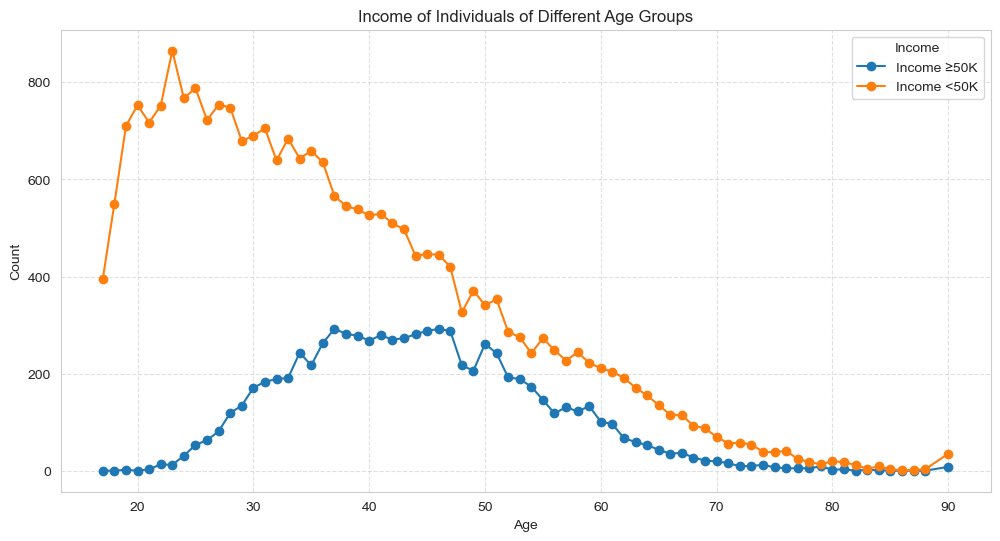

In [4]:
income_by_age = df.groupby(["age", "income"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.plot(
    income_by_age.index,
    income_by_age[">50K"],
    marker="o",
    linestyle="-",
    color="#1f77b4",
    label="Income ≥50K"
)
plt.plot(
    income_by_age.index,
    income_by_age["<=50K"],
    marker="o",
    linestyle="-",
    color="#ff7f0e",
    label="Income <50K"
)

plt.title("Income of Individuals of Different Age Groups")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Income")
plt.show()

### Insight
- Most younger individuals fall into the lower-income group.
- Higher-income counts rise through mid-career years and then decline later.
- This suggests different outreach strategies may be needed for early-career, mid-career, and older adult learners.

## 5. Analysis 2: Education Level and Income
Convert education into an ordered category and compare income distribution across education levels.

/var/folders/2j/kf1h4css0gg3htvyw9yq8lsm0000gn/T/ipykernel_92476/2873513375.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_income = df.groupby(["education", "income"]).size().unstack()


<Figure size 1200x600 with 0 Axes>

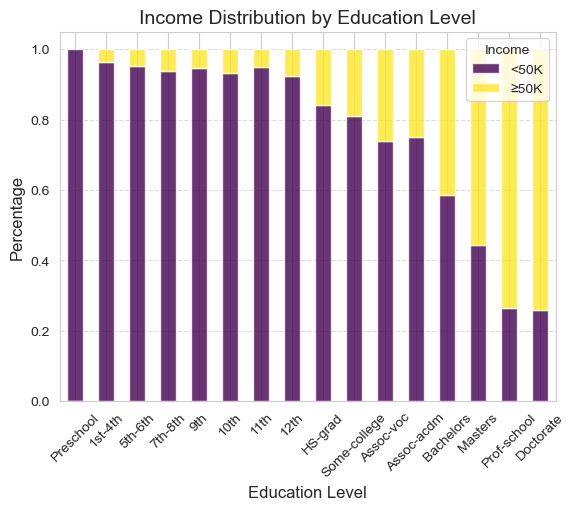

In [5]:
df = df.sort_values("education")

education_income = df.groupby(["education", "income"]).size().unstack()
education_income_percentage = education_income.div(education_income.sum(axis=1), axis=0)

plt.figure(figsize=(12, 6))
education_income_percentage.plot(kind="bar", stacked=True, colormap="viridis", alpha=0.8)

plt.title("Income Distribution by Education Level", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Percentage", fontsize=12)
plt.legend(title="Income", labels=["<50K", "≥50K"])
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Insight
- Lower education levels are heavily concentrated in the below-\$50K group.
- Bachelor's, Master's, professional, and doctorate levels show much stronger high-income representation.
- Education appears to be one of the strongest variables associated with income.

## 6. Analysis 3: Hours Per Week, Capital Gain, and Income
Use a scatter plot to compare work hours, capital gain, and income class.

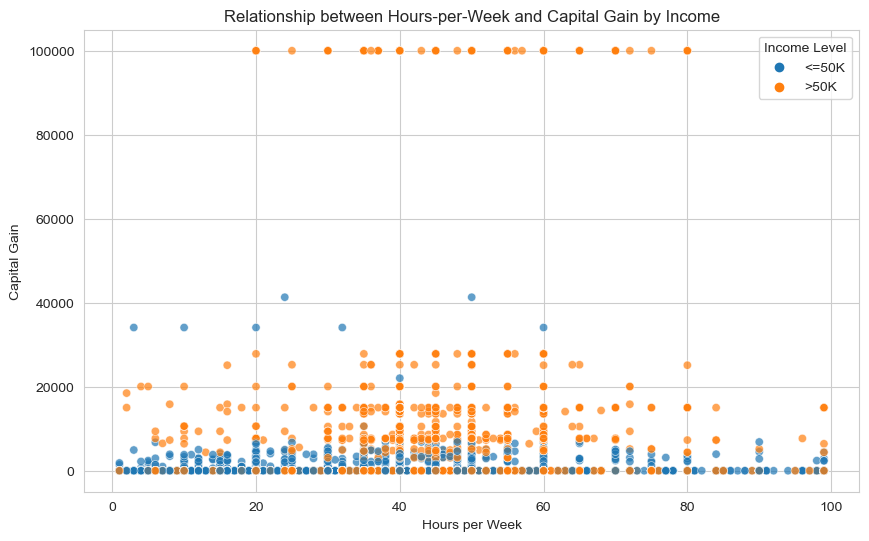

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="hours-per-week",
    y="capital-gain",
    hue="income",
    data=df,
    alpha=0.7
)

plt.title("Relationship between Hours-per-Week and Capital Gain by Income")
plt.xlabel("Hours per Week")
plt.ylabel("Capital Gain")
plt.legend(title="Income Level")
plt.show()

### Insight
- Most lower-income individuals have very low capital gain values.
- Higher-income individuals are more likely to have larger capital gains.
- Work hours alone do not appear to fully explain income differences.

## 7. Analysis 4: Occupation, Gender, and Income
Drop rows with missing values for this view, then compare gender proportions within each occupation and income class.

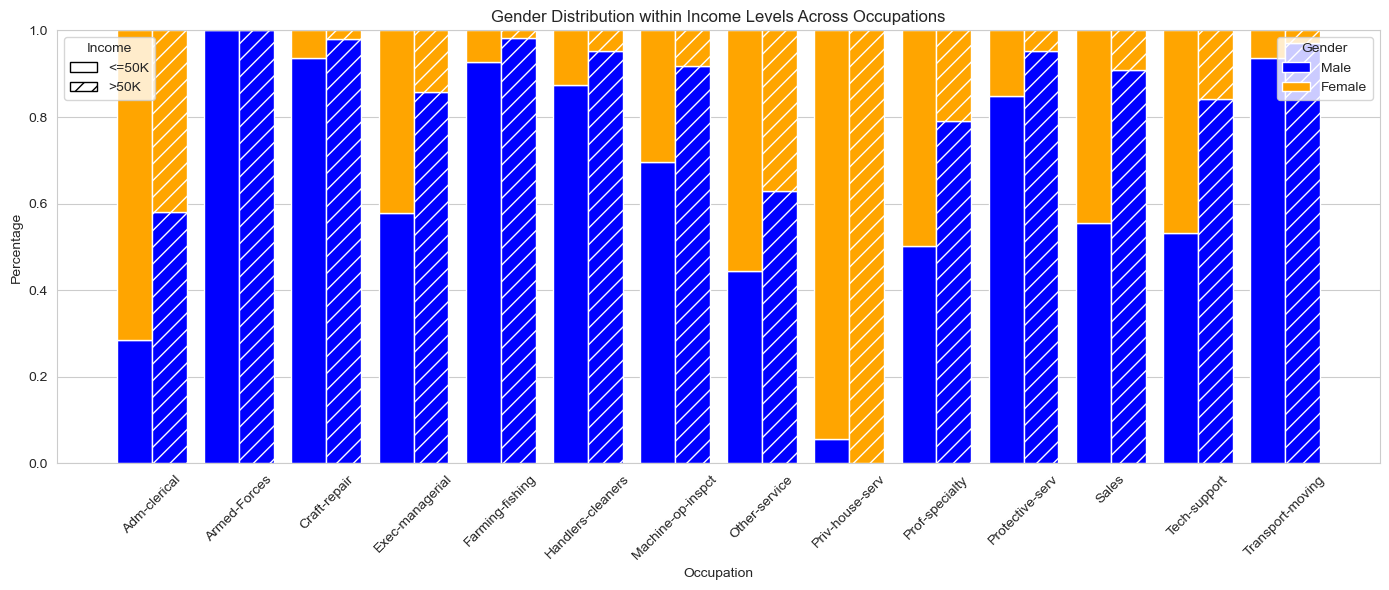

In [7]:
df_occ = df.dropna().copy()
df_occ["income"] = df_occ["income"].str.strip()

df_grouped = (
    df_occ.groupby(["occupation", "income", "sex"])
    .size()
    .reset_index(name="count")
)

df_grouped["total"] = df_grouped.groupby(["occupation", "income"])["count"].transform("sum")
df_grouped["percent"] = df_grouped["count"] / df_grouped["total"]

occupation_list = sorted(df_occ["occupation"].unique())

plt.figure(figsize=(14, 6))
x_indexes = np.arange(len(occupation_list))
width = 0.4
income_hatch = {"<=50K": None, ">50K": "//"}

for i, income_type in enumerate(["<=50K", ">50K"]):
    sub_df = df_grouped[df_grouped["income"] == income_type]

    male_percent = (
        sub_df[sub_df["sex"] == "Male"]
        .set_index("occupation")["percent"]
        .reindex(occupation_list, fill_value=0)
    )
    female_percent = (
        sub_df[sub_df["sex"] == "Female"]
        .set_index("occupation")["percent"]
        .reindex(occupation_list, fill_value=0)
    )

    plt.bar(
        x_indexes + i * width,
        male_percent,
        width=width,
        color="blue",
        label="Male" if i == 0 else None,
        hatch=income_hatch[income_type]
    )
    plt.bar(
        x_indexes + i * width,
        female_percent,
        bottom=male_percent,
        width=width,
        color="orange",
        label="Female" if i == 0 else None,
        hatch=income_hatch[income_type]
    )

plt.xticks(x_indexes + width / 2, occupation_list, rotation=45)
plt.xlabel("Occupation")
plt.ylabel("Percentage")
plt.title("Gender Distribution within Income Levels Across Occupations")

legend_income = [
    Patch(facecolor="white", edgecolor="black", hatch=None, label="<=50K"),
    Patch(facecolor="white", edgecolor="black", hatch="//", label=">50K"),
]
legend_sex = [
    Patch(facecolor="blue", label="Male"),
    Patch(facecolor="orange", label="Female"),
]

legend1 = plt.legend(handles=legend_income, title="Income", loc="upper left")
plt.gca().add_artist(legend1)
plt.legend(handles=legend_sex, title="Gender", loc="upper right")
plt.tight_layout()
plt.show()

### Insight
- Some occupations are strongly male-dominated, especially in higher-income groups.
- Administrative and service roles show larger female representation, especially in lower-income brackets.
- Occupational differences may be useful for audience segmentation and program positioning.

## 8. Analysis 5: Education Level, Race, and Income
Use a box plot to compare years of education (`education-num`) across race and income groups.

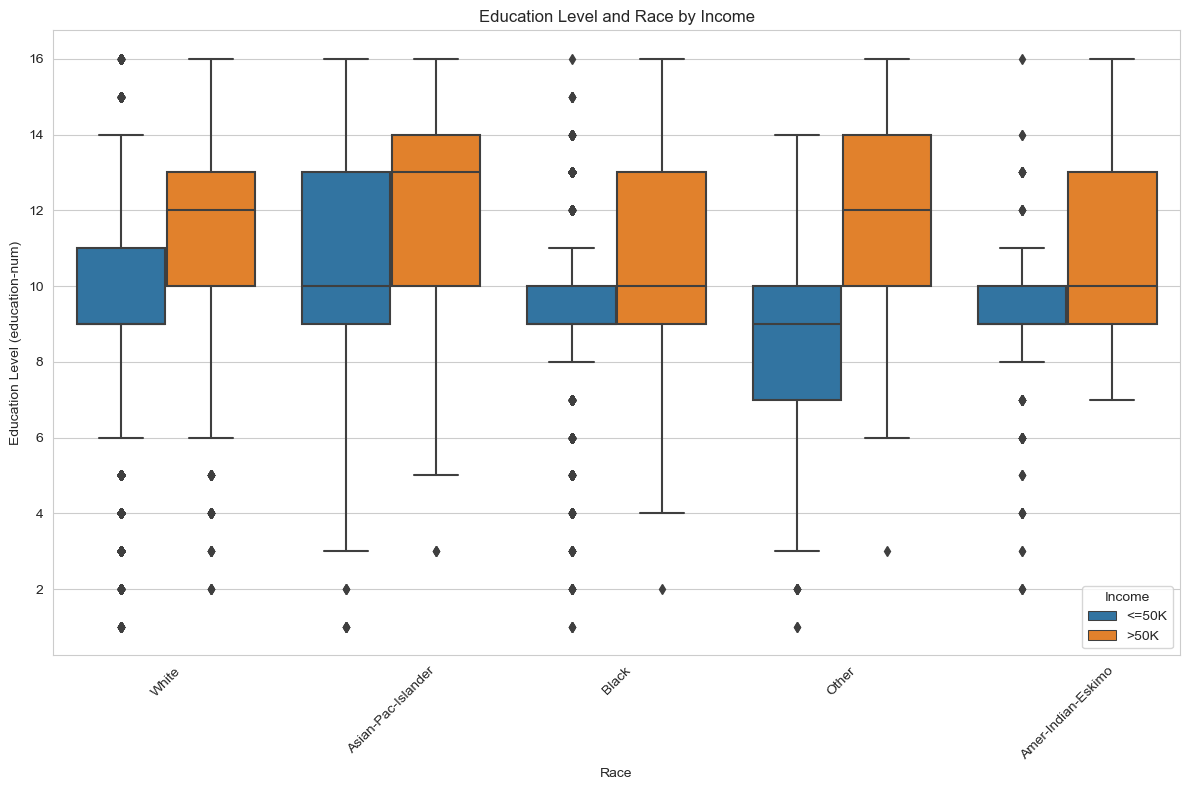

In [8]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    x="race",
    y="education-num",
    hue="income",
    data=df_occ,
    palette=["#1f77b4", "#ff7f0e"]
)

plt.title("Education Level and Race by Income")
plt.xlabel("Race")
plt.ylabel("Education Level (education-num)")
plt.xticks(rotation=45)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

### Insight
- Higher education is associated with higher income across racial groups.
- The distribution of education differs across groups, which may affect income patterns.
- Outreach strategy can be tailored by both education level and audience segment.

## 9. Summary of Findings
Across the analyses, several patterns appear consistently:

1. Age is associated with income, with higher-income counts rising during mid-career years.
2. Education is strongly associated with income.
3. Capital gain is more common among higher-income individuals.
4. Occupation and gender distributions vary meaningfully by income class.
5. Education and race together reveal differences in how income is distributed across groups.

These findings can support college marketing strategies aimed at working adults, lower-income segments, and individuals seeking career advancement through education.

## 10. Next Steps
Possible extensions to this notebook:

- add preprocessing and modeling into a scikit-learn pipeline
- evaluate a baseline classifier for income prediction
- export cleaned data and figures for reuse in the full project repository
- turn key outputs into a small dashboard or executive summary